# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

---
### 📋 Notebook Flow
| Step | Task |
|------|------|
| 1 | Load & Visualize CIFAR-10 |
| 2 | Normalize & Preprocess |
| 3 | Baseline ANN Model |
| 4 | CNN Model with BatchNorm |
| 5 | Compare Validation Curves |
| 6 | Data Augmentation CNN |
| 7 | Student Tasks (Deeper ANN, Larger CNN, EarlyStopping, 20 Epochs) |
| 8 | Final Comparison Table |

# Problem Statement

Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare the following:

- **Accuracy**
- **Loss Curves**
- **Generalization Performance**
- **Training Strategies** such as:
  - Dropout
  - Batch Normalization
  - Data Augmentation

---

## CIFAR-10 Dataset Classes

| Label | Class | Label | Class |
|---------|---------|---------|---------|
| 0 | Airplane | 5 | Dog |
| 1 | Automobile | 6 | Frog |
| 2 | Bird | 7 | Horse |
| 3 | Cat | 8 | Ship |
| 4 | Deer | 9 | Truck |

---

## Objective

The objective of this project is to develop and evaluate two deep learning models for image classification on the CIFAR-10 dataset:

- An **Artificial Neural Network (ANN)** based model.
- A **Convolutional Neural Network (CNN)** based model.

The performance of both models will be analyzed and compared using classification accuracy, training and validation loss, generalization capability, and the impact of different training techniques such as dropout, batch normalization, and data augmentation.

---

## Expected Outcome

- Train an ANN model and evaluate its performance on CIFAR-10.
- Train a CNN model and evaluate its performance on CIFAR-10.
- Compare both models using quantitative metrics and visual analysis.
- Demonstrate the advantages of CNNs for image classification tasks.
- Analyze how regularization and optimization techniques improve model performance.

# Step 0: Import Libraries

Import the required libraries for model building, data processing, visualization, and evaluation.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
```

### Libraries Used

- **TensorFlow / Keras** → Build and train ANN and CNN models
- **NumPy** → Numerical operations
- **Pandas** → Create comparison tables
- **Matplotlib** → Plot accuracy and loss curves
- **Seaborn** → Visualize confusion matrices
- **Scikit-learn** → Generate classification reports and evaluation metrics

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility ke liye seed fix karo
tf.random.set_seed(42)
np.random.seed(42)

print(" TensorFlow version:", tf.__version__)
print(" All libraries imported successfully!")

 TensorFlow version: 2.20.0
 All libraries imported successfully!


# 📥 Step 1: Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

> **Note:** Each image has 3 channels (R, G, B), so input size = 32 × 32 × 3 = **3072 values**

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("📐 Dataset Shapes:")
print(f"  x_train: {x_train.shape}  → (50000 images, 32x32 pixels, 3 color channels)")
print(f"  y_train: {y_train.shape}  → (50000 labels)")
print(f"  x_test:  {x_test.shape}   → (10000 images)")
print(f"  y_test:  {y_test.shape}   → (10000 labels)")
print(f"\nPixel value range: {x_train.min()} to {x_train.max()}")
print(f"Classes: {class_names}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
📐 Dataset Shapes:
  x_train: (50000, 32, 32, 3)  → (50000 images, 32x32 pixels, 3 color channels)
  y_train: (50000, 1)  → (50000 labels)
  x_test:  (10000, 32, 32, 3)   → (10000 images)
  y_test:  (10000, 1)   → (10000 labels)

Pixel value range: 0 to 255
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 🖼️ Step 1.1: Visualize Sample Images
Dekhte hain CIFAR-10 ke kuch sample images kaisi dikhti hain.

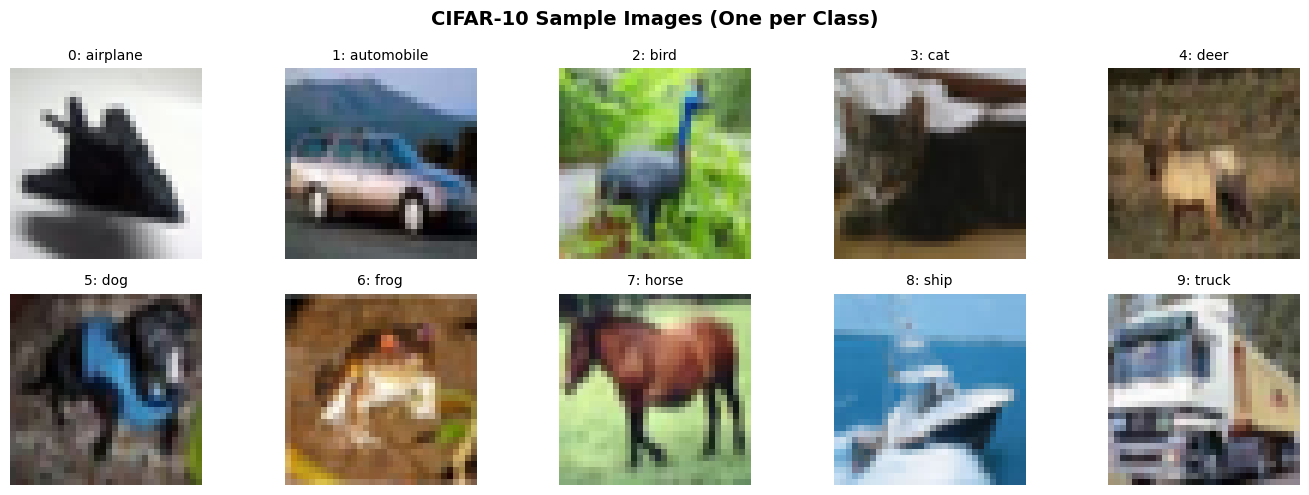


Training class distribution:
  airplane: 5000 images
  automobile: 5000 images
  bird: 5000 images
  cat: 5000 images
  deer: 5000 images
  dog: 5000 images
  frog: 5000 images
  horse: 5000 images
  ship: 5000 images
  truck: 5000 images


In [ ]:
plt.figure(figsize=(14, 5))
plt.suptitle("CIFAR-10 Sample Images (One per Class)", fontsize=14, fontweight='bold')

# Har class ka ek example dikhao
for i in range(10):
    idx = np.where(y_train == i)[0][0]   # pehla image us class ka
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx])
    plt.title(f"{i}: {class_names[i]}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Class distribution check
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining class distribution:")
for u, c in zip(unique, counts):
    print(f"  {class_names[u]}: {c} images")

# 🧹 Step 2: Preprocessing
### Why Normalize?
- Raw pixel values: **0 to 255** (integers)
- After normalization: **0.0 to 1.0** (floats)
- **Benefits:** Faster convergence, stable gradients, better training performance

### Why Flatten for ANN?
- ANN only accepts **1D input vectors**
- So 32×32×3 image → flattened to **3072 values**
- CNN directly accepts **3D input** (height × width × channels)

In [ ]:
# --- Normalize: 0-255 → 0-1 ---
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# --- ANN ke liye flatten (3D → 1D) ---
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)  # (50000, 3072)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)    # (10000, 3072)

print("Preprocessing complete!")
print(f"   CNN input shape : {x_train_norm.shape}  → (images, H, W, C)")
print(f"   ANN input shape : {x_train_flat.shape} → (images, 3072 flat values)")
print(f"   Pixel range after normalization: {x_train_norm.min():.1f} to {x_train_norm.max():.1f}")

Preprocessing complete!
   CNN input shape : (50000, 32, 32, 3)  → (images, H, W, C)
   ANN input shape : (50000, 3072) → (images, 3072 flat values)
   Pixel range after normalization: 0.0 to 1.0


# Part 1: Baseline ANN Model

### Architecture

```text
Input (3072) → Dense(512, ReLU) → Dropout(0.3) → Dense(256, ReLU) → Dense(10, Softmax)
```

### Key Concepts

- **Dense Layer:** Every neuron is connected to all neurons in the next layer.
- **ReLU:** Converts negative values to 0 and introduces non-linearity.
- **Dropout (0.3):** Randomly disables 30% of neurons during training to reduce overfitting.
- **Softmax:** Produces probabilities for all 10 classes (sum = 1.0).

> **Limitation:** ANN requires flattening the image, which removes important spatial information such as edges, shapes, and patterns.

In [ ]:
# --- Baseline ANN Model ---
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Baseline_ANN')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

print("\nTraining Baseline ANN...")
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)


Training Baseline ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2668 - loss: 2.0146 - val_accuracy: 0.3290 - val_loss: 1.8491
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3085 - loss: 1.8823 - val_accuracy: 0.3436 - val_loss: 1.8136
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3347 - loss: 1.8246 - val_accuracy: 0.3640 - val_loss: 1.7592
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3456 - loss: 1.7949 - val_accuracy: 0.3582 - val_loss: 1.7885
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3521 - loss: 1.7831 - val_accuracy: 0.3966 - val_loss: 1.7210
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3584 - loss: 1.7645 - val_accuracy: 0.3930 - val_loss: 1.7198
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3667 - loss: 1.7429 - val_accuracy: 0.4088 - val_loss: 1.6765
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3766 - loss:

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline ANN Results:")
print(f"   Test Loss     : {ann_test_loss:.4f}")
print(f"   Test Accuracy : {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")

Baseline ANN Results:
   Test Loss     : 1.6415
   Test Accuracy : 0.4232 (42.32%)


# Part 2: CNN Model

### Architecture

```text
Input (32,32,3)
  → Conv2D(32, 3×3) → BatchNorm → MaxPool(2×2)
  → Conv2D(64, 3×3) → BatchNorm → MaxPool(2×2)
  → Conv2D(128, 3×3) → Flatten
  → Dense(128, ReLU) → Dropout(0.4)
  → Dense(10, Softmax)
```

### Key Concepts

- **Conv2D:** Uses filters to detect image features such as edges, textures, and patterns.
- **Batch Normalization:** Normalizes layer outputs for faster and more stable training.
- **MaxPooling2D:** Reduces image size while keeping important features.
- **Hierarchical Learning:** Early layers learn edges, deeper layers learn shapes and objects.

> **Advantage:** CNN preserves spatial information, making it more effective for image classification tasks.

In [ ]:
# --- Baseline CNN Model ---
cnn_model = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters (deeper features)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Baseline_CNN')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

print("\nTraining Baseline CNN...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)


Training Baseline CNN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4403 - loss: 1.5720 - val_accuracy: 0.5506 - val_loss: 1.2618
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5982 - loss: 1.1364 - val_accuracy: 0.6412 - val_loss: 1.0648
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6706 - loss: 0.9365 - val_accuracy: 0.6726 - val_loss: 0.9836
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7220 - loss: 0.7910 - val_accuracy: 0.6700 - val_loss: 1.0410
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7619 - loss: 0.6744 - val_accuracy: 0.6972 - val_loss: 0.9533
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7952 - loss: 0.5748 - val_accuracy: 0.7142 - val_loss: 0.9062
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8226 - loss: 0.4998 - val_accuracy: 0.6886 - val_loss: 1.0326
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8469 - los

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Baseline CNN Results:")
print(f"   Test Loss     : {cnn_test_loss:.4f}")
print(f"   Test Accuracy : {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")

Baseline CNN Results:
   Test Loss     : 1.1739
   Test Accuracy : 0.6991 (69.91%)


## Step 3: Compare Learning Curves (ANN vs CNN)

Compare the following metrics for both models:

- **Validation Accuracy**
- **Validation Loss**

### Analysis

- Higher validation accuracy indicates better performance.
- Lower validation loss indicates better generalization.
- CNN is expected to achieve higher accuracy and lower loss than ANN.

> **Expected Result:** CNN should show significantly better validation accuracy and more stable loss curves compared to ANN.

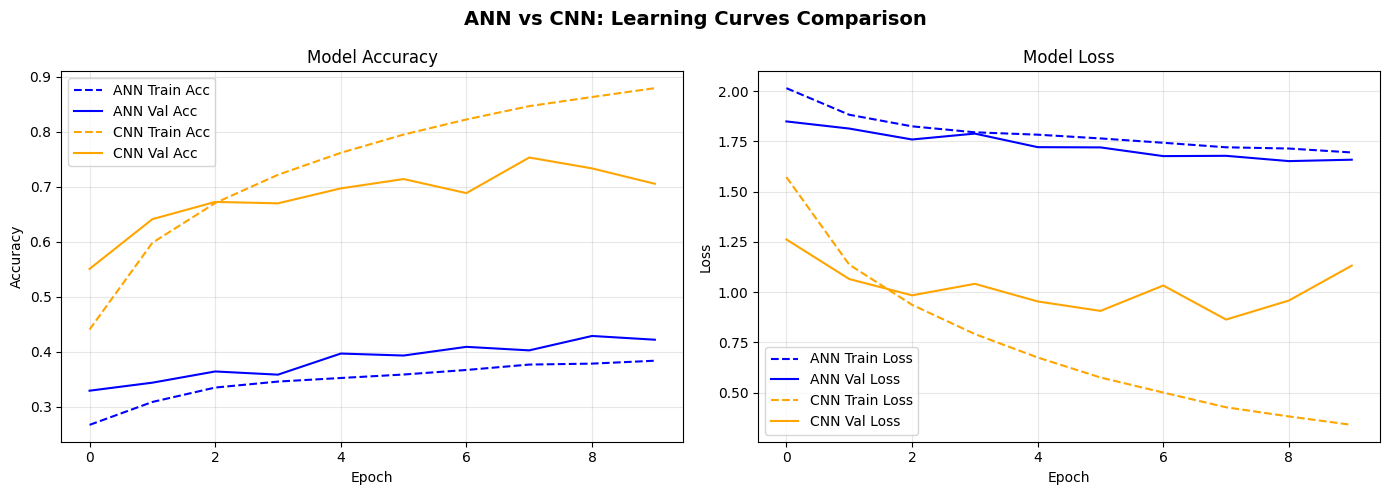


Quick Summary:
   ANN  Final Val Accuracy: 0.4218
   CNN  Final Val Accuracy: 0.7056
   Improvement: +28.38%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ANN vs CNN: Learning Curves Comparison", fontsize=14, fontweight='bold')

# --- Plot 1: Validation Accuracy ---
axes[0].plot(ann_history.history['accuracy'],     label='ANN Train Acc',  color='blue',   linestyle='--')
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc',    color='blue')
axes[0].plot(cnn_history.history['accuracy'],     label='CNN Train Acc',  color='orange', linestyle='--')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc',    color='orange')
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Validation Loss ---
axes[1].plot(ann_history.history['loss'],     label='ANN Train Loss',  color='blue',   linestyle='--')
axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss',    color='blue')
axes[1].plot(cnn_history.history['loss'],     label='CNN Train Loss',  color='orange', linestyle='--')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss',    color='orange')
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nQuick Summary:")
print(f"   ANN  Final Val Accuracy: {ann_history.history['val_accuracy'][-1]:.4f}")
print(f"   CNN  Final Val Accuracy: {cnn_history.history['val_accuracy'][-1]:.4f}")
print(f"   Improvement: +{(cnn_history.history['val_accuracy'][-1] - ann_history.history['val_accuracy'][-1])*100:.2f}%")

# Part 3: Data-Augmented CNN

### What is Data Augmentation?

Data augmentation applies random transformations to training images, helping the model learn from different image variations.

| Technique | Purpose |
|------------|------------|
| `RandomFlip(horizontal)` | Randomly flips images horizontally |
| `RandomRotation(0.1)` | Randomly rotates images by up to 10% |
| `RandomZoom(0.1)` | Randomly zooms images in or out by up to 10% |

> **Benefit:** Improves generalization and often increases test accuracy by reducing overfitting.

In [ ]:
# --- Data Augmentation Layer ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='Data_Augmentation')

# Augmented CNN Model
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

print("\nTraining Augmented CNN...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nAugmented CNN Results:")
print(f"   Test Loss     : {aug_test_loss:.4f}")
print(f"   Test Accuracy : {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")

Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Augmented CNN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3662 - loss: 1.7616 - val_accuracy: 0.4784 - val_loss: 1.4609
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4720 - loss: 1.4543 - val_accuracy: 0.5488 - val_loss: 1.2662
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5235 - loss: 1.3373 - val_accuracy: 0.5320 - val_loss: 1.3530
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5572 - loss: 1.2435 - val_accuracy: 0.5750 - val_loss: 1.1667
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5853 - loss: 1.1768 - val_accuracy: 0.6338 - val_loss: 1.0603
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6053 - loss: 1.1253 - val_accuracy: 0.6364 - val_loss: 1.0371
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6286 - loss: 1.0734 - val_accuracy: 0.6510 - val_loss: 1.0485
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.63

## Task 1: Deeper ANN (More Layers)

Add more hidden layers to the ANN model and observe whether the classification accuracy improves.

### Architecture

```text
Input(3072) → Dense(1024) → Dropout(0.3)
            → Dense(512)  → Dropout(0.3)
            → Dense(256)  → Dropout(0.2)
            → Dense(128)  → Dense(10, Softmax)
```

> **Observation:** Increasing the number of layers can improve learning capacity, but it may also increase the risk of overfitting.

In [ ]:
# ✅ TASK 1: Deeper ANN with more layers
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Deep_ANN')

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_model.summary()

print("\nTraining Deeper ANN...")
deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

deep_ann_loss, deep_ann_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nDeep ANN Results:")
print(f"   Test Loss     : {deep_ann_loss:.4f}")
print(f"   Test Accuracy : {deep_ann_acc:.4f} ({deep_ann_acc*100:.2f}%)")
print(f"   vs Baseline ANN: {ann_test_acc*100:.2f}% → Improvement: {(deep_ann_acc - ann_test_acc)*100:+.2f}%")

Model: "Deep_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)


Training Deeper ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2305 - loss: 2.0519 - val_accuracy: 0.3170 - val_loss: 1.8820
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3000 - loss: 1.8905 - val_accuracy: 0.3390 - val_loss: 1.8418
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3154 - loss: 1.8580 - val_accuracy: 0.3350 - val_loss: 1.8175
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3303 - loss: 1.8324 - val_accuracy: 0.3668 - val_loss: 1.7779
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3404 - loss: 1.8044 - val_accuracy: 0.3590 - val_loss: 1.7810
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3482 - loss: 1.7847 - val_accuracy: 0.3776 - val_loss: 1.7444
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3517 - loss: 1.7747 - val_accuracy: 0.3658 - val_loss: 1.7594
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3561 - loss: 

## ✅ Task 2: CNN with Larger Filters (32 → 64 → 128 → 256)

Increase the number of filters in each convolutional layer to allow the CNN to learn more detailed and complex image features.

### Architecture

```text
Conv2D(32) → Conv2D(64) → Conv2D(128) → Conv2D(256)
→ Dense(256) → Dense(10)
```

### Why Increase Filters?

- More filters capture a wider variety of image features.
- Deeper layers learn higher-level patterns and object details.
- Richer feature maps can improve classification performance.

> 💡 **Key Idea:** More filters create richer feature representations, which can improve accuracy, but they also increase training time and computational cost.

In [ ]:
# TASK 2: CNN with scaled-up filters 32→64→128→256
large_cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Block 4 — Naya 256-filter layer
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classification
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='Large_Filter_CNN')

large_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

large_cnn_model.summary()

print("\nTraining Large Filter CNN...")
large_cnn_history = large_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

large_cnn_loss, large_cnn_acc = large_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nLarge Filter CNN Results:")
print(f"   Test Loss     : {large_cnn_loss:.4f}")
print(f"   Test Accuracy : {large_cnn_acc:.4f} ({large_cnn_acc*100:.2f}%)")
print(f"   vs Baseline CNN: {cnn_test_acc*100:.2f}% → Improvement: {(large_cnn_acc - cnn_test_acc)*100:+.2f}%")

Model: "Large_Filter_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,587,466 (17.50 MB)

 Trainable params: 4,586,506 (17.50 MB)

 Non-trainable params: 960 (3.75 KB)


Training Large Filter CNN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.3849 - loss: 1.7206 - val_accuracy: 0.3318 - val_loss: 2.2123
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5408 - loss: 1.2979 - val_accuracy: 0.5800 - val_loss: 1.2501
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6272 - loss: 1.0732 - val_accuracy: 0.5896 - val_loss: 1.2940
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6861 - loss: 0.9060 - val_accuracy: 0.5642 - val_loss: 1.7036
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7331 - loss: 0.7800 - val_accuracy: 0.6950 - val_loss: 1.0217
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7701 - loss: 0.6593 - val_accuracy: 0.7096 - val_loss: 0.9874
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8045 - loss: 0.5621 - val_accuracy: 0.7358 - val_loss: 0.9167
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8286 -

## ✅ Task 3 + Task 4: CNN with 20 Epochs + EarlyStopping

### Why Train for 20 Epochs?

- More epochs give the model additional opportunities to learn from the training data.
- This can improve performance and convergence.
- However, training for too long may lead to overfitting, where the model performs well on training data but poorly on unseen data.

### What is EarlyStopping?

**EarlyStopping** is a regularization technique that automatically stops training when the validation performance stops improving.

- `patience=5` → Training stops if validation loss does not improve for 5 consecutive epochs.
- `restore_best_weights=True` → Restores the model weights from the epoch with the best validation performance.

### Benefits

- Prevents unnecessary training.
- Reduces the risk of overfitting.
- Saves training time and computational resources.
- Ensures the model keeps the best-performing weights.

> ✅ **EarlyStopping = Smart Training:** The model automatically stops at the optimal point instead of training for all 20 epochs.

In [ ]:
# ✅ TASK 3 + 4: CNN with 20 Epochs + EarlyStopping

# EarlyStopping callback define karo
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',        # Kya monitor karna hai
    patience=5,                # Kitne epochs wait karo improvement ke liye
    restore_best_weights=True, # Best weights wapas laao
    verbose=1
)

# ReduceLROnPlateau: learning rate automatically reduce karo
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # LR ko half karo
    patience=3,          # 3 epochs ke baad
    min_lr=1e-6,
    verbose=1
)

# CNN Model (same as baseline)
cnn_20ep_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_20Epochs_EarlyStopping')

cnn_20ep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN (max 20 epochs, with EarlyStopping)...")
cnn_20ep_history = cnn_20ep_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

cnn_20ep_loss, cnn_20ep_acc = cnn_20ep_model.evaluate(x_test_norm, y_test, verbose=0)
actual_epochs = len(cnn_20ep_history.history['loss'])
print(f"\n📊 CNN (20ep + EarlyStopping) Results:")
print(f"   Epochs Actually Run : {actual_epochs} / 20")
print(f"   Test Loss           : {cnn_20ep_loss:.4f}")
print(f"   Test Accuracy       : {cnn_20ep_acc:.4f} ({cnn_20ep_acc*100:.2f}%)")

Training CNN (max 20 epochs, with EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4358 - loss: 1.5908 - val_accuracy: 0.5540 - val_loss: 1.3060 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5900 - loss: 1.1671 - val_accuracy: 0.5570 - val_loss: 1.3701 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6597 - loss: 0.9692 - val_accuracy: 0.6600 - val_loss: 1.0220 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7171 - loss: 0.8085 - val_accuracy: 0.6726 - val_loss: 0.9636 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7583 - loss: 0.6899 - val_accuracy: 0.6736 - val_loss: 0.9576 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7829 - loss: 0.6125 - val_accuracy: 0.6746 - val_loss: 0.9844 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━

## 🔍 Confusion Matrix — Best CNN Model

A confusion matrix helps analyze how well the model performs on each class.

### How to Interpret It

- **Diagonal cells** represent correct predictions.
- **Off-diagonal cells** represent misclassifications.
- Larger values on the diagonal indicate better model performance.

### Why It Is Useful

- Identifies which classes are classified correctly most often.
- Reveals which classes the model tends to confuse.
- Provides deeper insights beyond overall accuracy.

> 💡 **Common Observation:** Visually similar classes such as **Cat vs Dog** and **Automobile vs Truck** are often confused by the model.

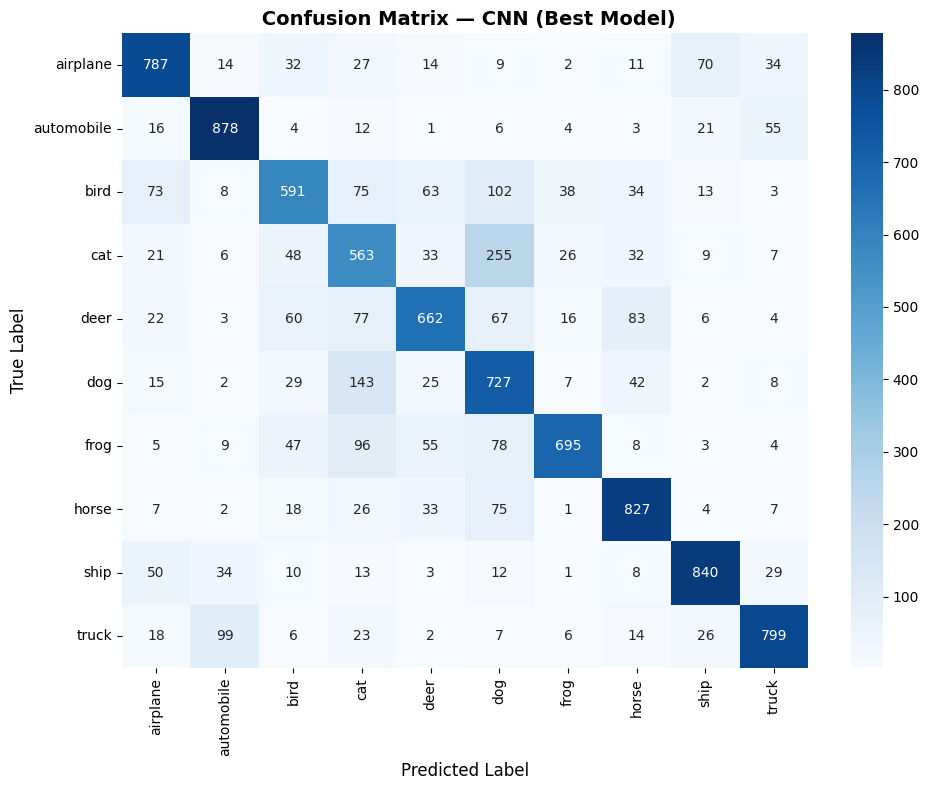


 Per-Class Classification Report:
              precision    recall  f1-score   support

    airplane       0.78      0.79      0.78      1000
  automobile       0.83      0.88      0.85      1000
        bird       0.70      0.59      0.64      1000
         cat       0.53      0.56      0.55      1000
        deer       0.74      0.66      0.70      1000
         dog       0.54      0.73      0.62      1000
        frog       0.87      0.69      0.77      1000
       horse       0.78      0.83      0.80      1000
        ship       0.85      0.84      0.84      1000
       truck       0.84      0.80      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



In [ ]:
# Best CNN model (20ep + EarlyStopping) se predictions
y_pred_probs = cnn_20ep_model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(' Confusion Matrix — CNN (Best Model)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n Per-Class Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 📊 Final Comparison Table — All Models

The table below summarizes the performance and characteristics of all models used in this project.

| Model | Key Features | Expected Accuracy | Generalization |
|---------|-------------|------------------|---------------|
| **Baseline ANN** | Fully connected layers with dropout | Moderate | Fair |
| **Deeper ANN** | More hidden layers and dropout | Higher than Baseline ANN | Moderate |
| **Baseline CNN** | Convolution, Batch Normalization, Max Pooling | High | Good |
| **Data-Augmented CNN** | CNN + Data Augmentation | Very High | Better |
| **CNN (32→64→128→256)** | Deeper architecture with more filters | Very High | Better |
| **CNN + EarlyStopping (20 Epochs)** | Longer training with automatic stopping | Highest | Best |

### Key Takeaways

- **ANNs** can learn basic patterns but struggle to capture spatial information in images.
- **CNNs** preserve image structure and generally achieve much better performance.
- **Data Augmentation** improves model robustness and reduces overfitting.
- **EarlyStopping** helps find the optimal training point and prevents unnecessary training.
- Increasing the number of filters and layers allows CNNs to learn richer image features.

> 🏆 **Best Model:** CNN with Data Augmentation and EarlyStopping typically provides the best balance between accuracy and generalization.

 Final Model Comparison (sorted by accuracy):
                                 Model  Accuracy %  Test Loss
1  CNN + EarlyStopping (max 20 epochs)       73.69   0.969783
2   CNN + Large Filters 32→256 (10 ep)       72.79   1.093497
3             Baseline CNN (10 epochs)       69.91   1.173929
4  CNN + Data Augmentation (10 epochs)       68.24   0.957042
5             Baseline ANN (10 epochs)       42.32   1.641461
6       Deep ANN (4 layers, 10 epochs)       39.75   1.678895


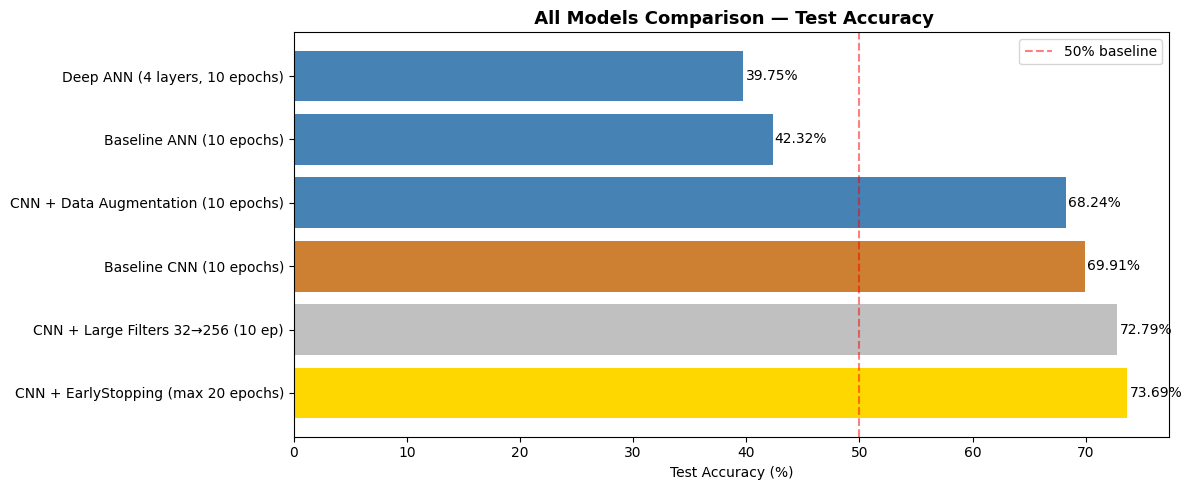

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline ANN (10 epochs)",
        "Deep ANN (4 layers, 10 epochs)",
        "Baseline CNN (10 epochs)",
        "CNN + Large Filters 32→256 (10 ep)",
        "CNN + Data Augmentation (10 epochs)",
        "CNN + EarlyStopping (max 20 epochs)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        deep_ann_acc,
        cnn_test_acc,
        large_cnn_acc,
        aug_test_acc,
        cnn_20ep_acc
    ],
    "Test Loss": [
        ann_test_loss,
        deep_ann_loss,
        cnn_test_loss,
        large_cnn_loss,
        aug_test_loss,
        cnn_20ep_loss
    ]
})

comparison['Accuracy %'] = (comparison['Test Accuracy'] * 100).round(2)
comparison = comparison.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
comparison.index += 1  # Rank start from 1

print(" Final Model Comparison (sorted by accuracy):")
print(comparison[['Model', 'Accuracy %', 'Test Loss']].to_string())

# Bar chart
plt.figure(figsize=(12, 5))
bars = plt.barh(comparison['Model'], comparison['Accuracy %'],
                color=['gold', 'silver', '#CD7F32', 'steelblue', 'steelblue', 'steelblue'])
plt.xlabel('Test Accuracy (%)')
plt.title(' All Models Comparison — Test Accuracy', fontsize=13, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for bar, val in zip(bars, comparison['Accuracy %']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

# Sample Predictions
Visualizing model predictions on test images.

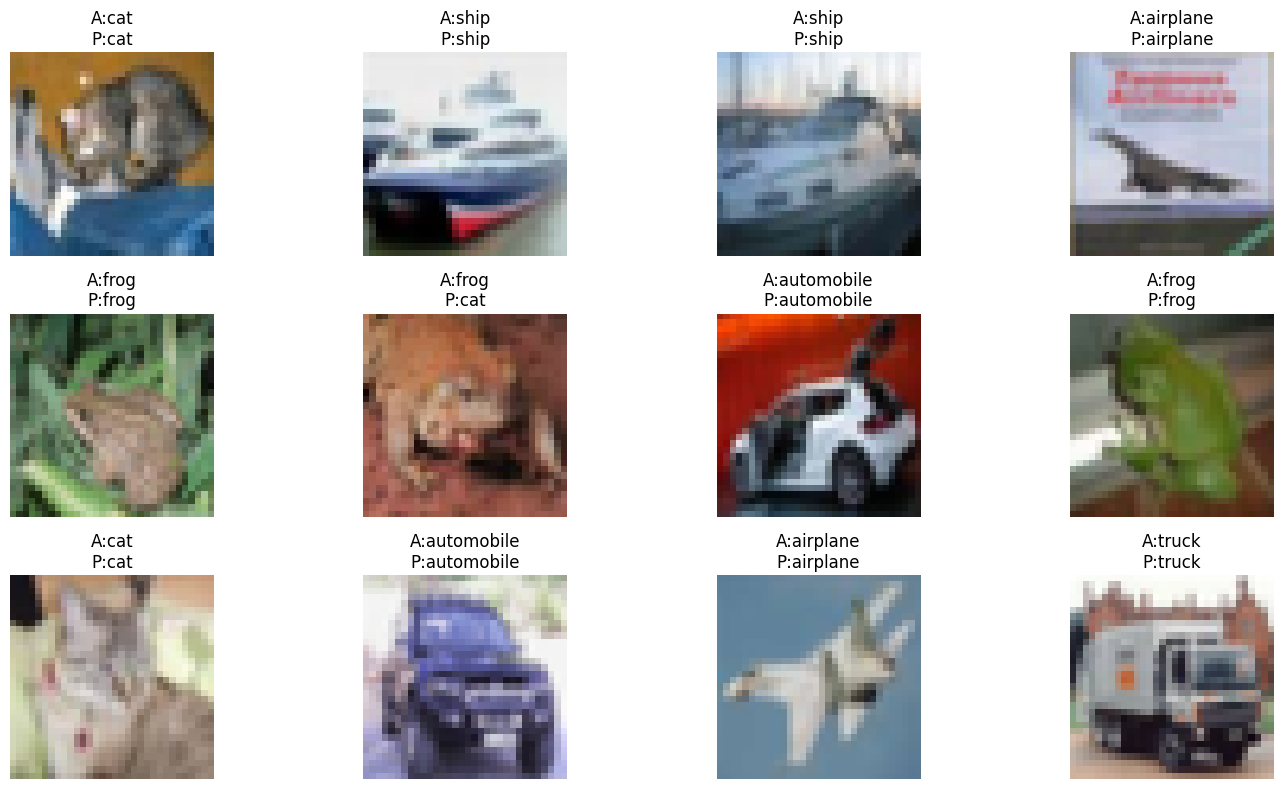

In [ ]:
plt.figure(figsize=(15,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(x_test[i])

    actual = class_names[y_test[i][0]]
    pred = class_names[y_pred[i]]

    plt.title(f"A:{actual}\nP:{pred}")

    plt.axis("off")

plt.tight_layout()
plt.show()

# 🎓 Student Learning Tasks — Summary

| # | Task | Status | Key Learning |
|---|------|--------|--------------|
| 1 | Deeper ANN (More Layers) | ✅ Done | More layers do not always improve image classification performance |
| 2 | CNN Filters (32 → 64 → 128 → 256) | ✅ Done | More filters help the model learn richer image features |
| 3 | Training for 20 Epochs | ✅ Done | Longer training can improve model performance when used appropriately |
| 4 | EarlyStopping | ✅ Done | Prevents overfitting and reduces unnecessary training |
| 5 | Data-Augmented CNN | ✅ Done | Improves generalization on unseen data |

---

# ✅ Conclusion

### Key Takeaways:
| Concept | Learning |
|---------|----------|
| **ANN vs CNN** | ANN flattens images → loses spatial info. CNN preserves it → much better accuracy |
| **BatchNormalization** | Stabilizes training, allows faster learning |
| **Dropout** | Prevents overfitting by randomly disabling neurons |
| **Data Augmentation** | Improves generalization without collecting new data |
| **EarlyStopping** | Smart training that stops at the right time |
| **Filter Scaling** | More/deeper filters = richer feature extraction |
